# Troisième étape de modélisation: deuxième limite - Questions 1.2.5

In [19]:
import math
import numpy as np
import matplotlib.pyplot as plt
from statistics import NormalDist
import pandas as pd

rng = np.random.default_rng(42)

from helpers.helpers_QRNIID import *
from helpers.helpers_QR2LIM import *
from helpers.helpers_AMS import *

rng = np.random.default_rng(42)


In [20]:
# Paramètres
q0 = 20
a_second = 2.0

mu_plus = 1.0
mu_minus = 1.1
alpha = 0.50
beta = 0.50
lambda_floor = 1e-8
gamma_cross = 1.0
eta = alpha / beta
lambda_minus_theory = theoretical_stationary_lambda_minus(mu_plus, mu_minus, alpha, beta)
q2_0 = q0
lambda_second_add = mu_plus
lambda_second_remove = lambda_minus_theory
b_second = beta

## 3. Méthode de splitting adaptatif multi-niveaux (AMS)

On cherche à estimer des probabilités rares du type

$$
\mathbb{P}\left(N^{+2}_{\tau}\le h\mid N^{+1}_{\tau}=0\right),
\qquad
\mathbb{P}\left(N^{+2}_{\tau}\le h\mid N^{-1}_{\tau}=0\right).
$$

L'idée de l'AMS est de ne pas attendre directement l'événement rare. On introduit un score de rareté, ici fondé sur la baisse de la deuxième limite :

$$
S(\omega)=q_2(0)-\min_{0\le t\le \tau}N^{+2}_t.
$$

Plus le score est grand, plus la trajectoire s'est rapprochée de l'événement rare. À chaque itération, on élimine les trajectoires avec le score le plus faible, puis on les remplace par des copies de trajectoires plus rares, redémarrées à partir du premier instant où elles ont atteint le niveau intermédiaire courant.

**Remarque importante.** Cette première implémentation utilise le score $q_2(0)-\min_t N^{+2}_t$ pour guider le splitting, mais l'indicateur final reste bien $N^{+2}_{\tau}\le h$. C'est donc une implémentation pratique et robuste pour explorer les événements rares, à valider contre Monte Carlo naïf sur des seuils moins rares.

### 3.1 Vérification rapide du simulateur markovien complet

Cette cellule vérifie que le nouveau simulateur donne les mêmes objets que les fonctions précédentes : côté vidé en premier, temps d'arrêt, valeur de $N^{+2}_{\tau}$, minimum atteint par $N^{+2}$.

In [21]:
sim_kwargs = dict(
    q1_0=q0,
    q2_0=q2_0,
    mu_plus=mu_plus,
    mu_minus=mu_minus,
    alpha=alpha,
    beta=beta,
    lambda_second_add=lambda_second_add,
    lambda_second_remove=lambda_second_remove,
    a_second=a_second,
    b_second=b_second,
    gamma_cross=gamma_cross,
    t_max=10_000.0,
)

for k in range(5):
    path = simulate_reactive_path_stateful(rng=rng, **sim_kwargs)
    print(
        f"path {k}: first_empty={path['first_empty']}, "
        f"tau={path['tau']:.2f}, "
        f"N+2_tau={path['plus2_at_tau']}, "
        f"min_N+2={path['min_plus2']}, "
        f"score={path['score']}, "
        f"n_events={len(path['history'])}"
    )

path 0: first_empty=plus1, tau=80.37, N+2_tau=333, min_N+2=16, score=4, n_events=774
path 1: first_empty=minus1, tau=289.39, N+2_tau=1364, min_N+2=20, score=0, n_events=3193
path 2: first_empty=minus1, tau=332.92, N+2_tau=1337, min_N+2=19, score=1, n_events=3330
path 3: first_empty=minus1, tau=304.21, N+2_tau=1319, min_N+2=19, score=1, n_events=3236
path 4: first_empty=plus1, tau=395.72, N+2_tau=1708, min_N+2=19, score=1, n_events=4194


### 3.2 Estimation naïve de référence

Avant d'utiliser AMS, on estime la probabilité sur un échantillon Monte Carlo standard. Pour des événements de probabilité $10^{-4}$, cette estimation peut être nulle ou très bruitée, mais elle sert de référence sur des seuils moins rares.

In [22]:
# Choisir d'abord un seuil pas trop rare pour vérifier.
h_test = 150
n_naive_test = 5_000

naive_plus1 = naive_conditional_probability(
    h=h_test,
    target_first_empty="plus1",
    n_samples=n_naive_test,
    sim_kwargs=sim_kwargs,
    rng=rng,
)

naive_minus1 = naive_conditional_probability(
    h=h_test,
    target_first_empty="minus1",
    n_samples=n_naive_test,
    sim_kwargs=sim_kwargs,
    rng=rng,
)

for res in [naive_plus1, naive_minus1]:
    print(f"Condition: {res['target_first_empty']}")
    print(f"  h = {res['h']}")
    print(f"  denominator = {res['denominator']} / {res['n_samples']}")
    print(f"  numerator   = {res['numerator']}")
    print(f"  p_hat       = {res['p_hat']:.6g}")
    print(f"  se_hat      = {res['se_hat']:.3g}")

Condition: plus1
  h = 150
  denominator = 2549 / 5000
  numerator   = 4
  p_hat       = 0.00156924
  se_hat      = 0.000784
Condition: minus1
  h = 150
  denominator = 2513 / 5000
  numerator   = 27
  p_hat       = 0.0107441
  se_hat      = 0.00206


### 3.3 AMS pour une probabilité rare

On lance AMS pour estimer la probabilité jointe

$$
\mathbb{P}\left(N^{+2}_{\tau}\le h,\; N^{+1}_{\tau}=0\right)
$$

ou

$$
\mathbb{P}\left(N^{+2}_{\tau}\le h,\; N^{-1}_{\tau}=0\right).
$$

Ensuite, on divise par une estimation naïve de $\mathbb{P}(N^{+1}_{\tau}=0)$ ou $\mathbb{P}(N^{-1}_{\tau}=0)$, qui n'est pas rare dans ce modèle.

In [ ]:
# Paramètres AMS
h_rare = 15
n_particles = 300
kill_fraction = 0.10
max_iterations = 50
n_denom = 10_000

# Estimation du dénominateur non rare par Monte Carlo standard
denom_plus1, hit_prob = estimate_denominator_naive(
    n_samples=n_denom,
    target_first_empty="plus1",
    sim_kwargs=sim_kwargs,
    rng=rng,
)

denom_minus1, _ = estimate_denominator_naive(
    n_samples=n_denom,
    target_first_empty="minus1",
    sim_kwargs=sim_kwargs,
    rng=rng,
)

print(f"P(hit before t_max)        ≈ {hit_prob:.4f}")
print(f"P(N+1_tau = 0) denominator ≈ {denom_plus1:.4f}")
print(f"P(N-1_tau = 0) denominator ≈ {denom_minus1:.4f}")

P(hit before t_max)        ≈ 1.0000
P(N+1_tau = 0) denominator ≈ 0.5025
P(N-1_tau = 0) denominator ≈ 0.4943


In [24]:
ams_plus1 = ams_low_second_limit(
    h=h_rare,
    target_first_empty="plus1",
    n_particles=n_particles,
    kill_fraction=kill_fraction,
    max_iterations=max_iterations,
    rng=rng,
    **sim_kwargs,
)

ams_minus1 = ams_low_second_limit(
    h=h_rare,
    target_first_empty="minus1",
    n_particles=n_particles,
    kill_fraction=kill_fraction,
    max_iterations=max_iterations,
    rng=rng,
    **sim_kwargs,
)

p_cond_plus1 = ams_plus1["p_joint_estimate"] / denom_plus1 if denom_plus1 > 0 else np.nan
p_cond_minus1 = ams_minus1["p_joint_estimate"] / denom_minus1 if denom_minus1 > 0 else np.nan

print("AMS results")
print("-----------")
print(f"h = {h_rare}")
print()
print("Condition N+1_tau = 0")
print(f"  joint estimate       = {ams_plus1['p_joint_estimate']:.6g}")
print(f"  conditional estimate = {p_cond_plus1:.6g}")
print(f"  final fraction       = {ams_plus1['final_fraction']:.4f}")
print(f"  levels               = {ams_plus1['levels']}")
print()
print("Condition N-1_tau = 0")
print(f"  joint estimate       = {ams_minus1['p_joint_estimate']:.6g}")
print(f"  conditional estimate = {p_cond_minus1:.6g}")
print(f"  final fraction       = {ams_minus1['final_fraction']:.4f}")
print(f"  levels               = {ams_minus1['levels']}")

AMS results
-----------
h = 15

Condition N+1_tau = 0
  joint estimate       = 0
  conditional estimate = 0
  final fraction       = 0.0000
  levels               = [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4]

Condition N-1_tau = 0
  joint estimate       = 0
  conditional estimate = 0
  final fraction       = 0.0000
  levels               = [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4]


### 3.4 Répéter AMS pour obtenir une incertitude empirique

Une seule exécution AMS est bruitée. Pour le rapport, il vaut mieux répéter l'algorithme plusieurs fois avec des graines différentes, puis donner la moyenne et un écart-type empirique.

In [25]:
n_repeats = 5

rep_plus1 = repeat_ams(
    h=h_rare,
    target_first_empty="plus1",
    n_repeats=n_repeats,
    n_particles=n_particles,
    kill_fraction=kill_fraction,
    max_iterations=max_iterations,
    denom=denom_plus1,
    sim_kwargs=sim_kwargs,
)

rep_minus1 = repeat_ams(
    h=h_rare,
    target_first_empty="minus1",
    n_repeats=n_repeats,
    n_particles=n_particles,
    kill_fraction=kill_fraction,
    max_iterations=max_iterations,
    denom=denom_minus1,
    sim_kwargs=sim_kwargs,
)

print("Repeated AMS conditional estimates")
print("----------------------------------")
for label, rep in [("N+1_tau = 0", rep_plus1), ("N-1_tau = 0", rep_minus1)]:
    print(label)
    print(f"  estimates = {rep['estimates']}")
    print(f"  mean      = {rep['mean']:.6g}")
    print(f"  std       = {rep['std']:.3g}")
    print(f"  se        = {rep['se']:.3g}")

Repeated AMS conditional estimates
----------------------------------
N+1_tau = 0
  estimates = [0. 0. 0. 0. 0.]
  mean      = 0
  std       = 0
  se        = 0
N-1_tau = 0
  estimates = [0. 0. 0. 0. 0.]
  mean      = 0
  std       = 0
  se        = 0


### 3.5 Tracer les seuils adaptatifs

Les niveaux doivent globalement augmenter. S'ils stagnent longtemps, cela signifie que le score est peu discriminant ou que le nombre de particules est trop faible.

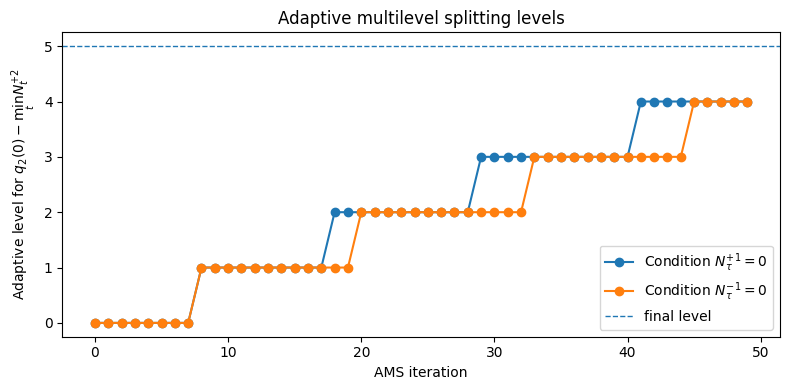

In [26]:
plt.figure(figsize=(8, 4))
plt.plot(ams_plus1["levels"], marker="o", label=r"Condition $N^{+1}_\tau=0$")
plt.plot(ams_minus1["levels"], marker="o", label=r"Condition $N^{-1}_\tau=0$")
plt.axhline(ams_plus1["final_level"], linestyle="--", linewidth=1, label="final level")
plt.xlabel("AMS iteration")
plt.ylabel(r"Adaptive level for $q_2(0)-\min_t N^{+2}_t$")
plt.title("Adaptive multilevel splitting levels")
plt.legend()
plt.tight_layout()
plt.show()

### 3.6 Boucle sur plusieurs valeurs de h

Cette cellule produit un tableau pour plusieurs seuils rares. Pour des seuils très petits, augmente `n_particles` et `n_repeats`.

In [27]:
h_grid = [8, 7, 6, 5, 4]
rows = []

for h in h_grid:
    out_p = repeat_ams(
        h=h,
        target_first_empty="plus1",
        n_repeats=3,
        n_particles=n_particles,
        kill_fraction=kill_fraction,
        max_iterations=max_iterations,
        denom=denom_plus1,
        sim_kwargs=sim_kwargs,
        seed=10_000 + h,
    )
    out_m = repeat_ams(
        h=h,
        target_first_empty="minus1",
        n_repeats=3,
        n_particles=n_particles,
        kill_fraction=kill_fraction,
        max_iterations=max_iterations,
        denom=denom_minus1,
        sim_kwargs=sim_kwargs,
        seed=20_000 + h,
    )
    rows.append({
        "h": h,
        "P(N+2_tau <= h | N+1_tau=0)_AMS": out_p["mean"],
        "SE_plus1": out_p["se"],
        "P(N+2_tau <= h | N-1_tau=0)_AMS": out_m["mean"],
        "SE_minus1": out_m["se"],
    })

ams_table = pd.DataFrame(rows)
display(ams_table)

KeyboardInterrupt: 